In [1]:
# Imports and core UMAP-from-scratch utilities
import numpy as np
from sklearn.datasets import fetch_openml
from sklearn.neighbors import NearestNeighbors
from scipy import sparse
import matplotlib.pyplot as plt

def smooth_knn_dist(knn_dists, k, local_connectivity=1.0, n_iter=64, tol=1e-5):
    n_samples, n_neighbors = knn_dists.shape
    rhos = np.zeros(n_samples, dtype=np.float32)
    sigmas = np.zeros(n_samples, dtype=np.float32)
    target = np.log2(k)

    for i in range(n_samples):
        dists = knn_dists[i]
        # Local connectivity: distance to the local_connectivity-th nearest neighbor
        lc = int(np.floor(local_connectivity))
        if lc > 0:
            rho = dists[lc - 1]
        else:
            rho = 0.0
        rhos[i] = rho

        # Helper to compute the sum for a given sigma
        def compute_sum(sigma):
            if sigma <= 0:
                return 0.0
            dd = dists - rho
            contrib = np.where(dd > 0, np.exp(-dd / sigma), 1.0)
            return np.sum(contrib)

        # Find an upper bound where sum >= target
        lo = 0.0
        hi = 1.0
        sum_hi = compute_sum(hi)
        guard = 0
        while sum_hi < target and guard < 32:
            lo = hi
            hi *= 2.0
            sum_hi = compute_sum(hi)
            guard += 1

        # Binary search for sigma
        for _ in range(n_iter):
            mid = (lo + hi) / 2.0
            if mid < 1e-12:
                mid = 1e-12
            s = compute_sum(mid)
            if abs(s - target) < tol:
                lo = hi = mid
                break
            if s > target:
                hi = mid
            else:
                lo = mid
        sigma = max(hi, 1e-12)
        sigmas[i] = sigma

    return rhos, sigmas

def fuzzy_simplicial_set(knn_indices, knn_dists, n_vertices, k, local_connectivity=1.0):
    rhos, sigmas = smooth_knn_dist(knn_dists, k, local_connectivity=local_connectivity)
    rows = []
    cols = []
    vals = []

    for i in range(n_vertices):
        rho = rhos[i]
        sigma = sigmas[i]
        for j in range(k):
            j_idx = knn_indices[i, j]
            d = knn_dists[i, j]
            if d - rho <= 0:
                p = 1.0
            else:
                p = np.exp(-(d - rho) / (sigma + 1e-12))
            rows.append(i)
            cols.append(j_idx)
            vals.append(p)

    P = sparse.csr_matrix((vals, (rows, cols)), shape=(n_vertices, n_vertices))
    # Symmetrize: p_ij = p_ij + p_ji - p_ij * p_ji
    PT = P.transpose()
    prod = P.multiply(PT)
    P = P + PT - prod
    P.setdiag(0.0)
    P.eliminate_zeros()
    return P

def find_ab_params(spread=1.0, min_dist=0.1):
    # Good defaults for min_dist=0.1 from UMAP literature
    # For simplicity we return constants; this is sufficient for typical usage.
    return 1.929, 0.7915

def umap_sgd(P, n_components=2, n_epochs=200, initial_lr=1.0, negative_sample_rate=5, a=1.929, b=0.7915, rng=None):
    if rng is None:
        rng = np.random.default_rng(42)
    n = P.shape[0]
    Y = (0.0001 * rng.standard_normal(size=(n, n_components))).astype(np.float32)

    coo = P.tocoo()
    heads = coo.row.astype(np.int64)
    tails = coo.col.astype(np.int64)
    weights = coo.data.astype(np.float32)

    for epoch in range(n_epochs):
        lr = initial_lr * (1.0 - (epoch / max(1, n_epochs)))
        order = rng.permutation(len(weights))
        for idx in order:
            if rng.random() > weights[idx]:
                continue
            i = heads[idx]
            j = tails[idx]
            diff = Y[i] - Y[j]
            r = float(np.dot(diff, diff)) + 1e-6
            # Attractive term
            grad_coeff = 2.0 * a * b * (r ** (b - 1.0)) / (1.0 + a * (r ** b))
            grad = grad_coeff * diff
            Y[i] -= lr * grad
            Y[j] += lr * grad
            # Negative samples
            for _ in range(negative_sample_rate):
                k = int(rng.integers(0, n))
                if k == i:
                    continue
                diffn = Y[i] - Y[k]
                rn = float(np.dot(diffn, diffn)) + 1e-6
                rep_coeff = 2.0 * b / (rn * (1.0 + a * (rn ** b)))
                gradn = rep_coeff * diffn
                Y[i] += lr * gradn
        # Optional: small recentring to stabilize
        Y -= np.mean(Y, axis=0, keepdims=True)
    return Y

def fit_umap(X, n_neighbors=15, n_components=2, n_epochs=200, lr=1.0, negative_sample_rate=5, min_dist=0.1, rng=None):
    if rng is None:
        rng = np.random.default_rng(42)
    # Build kNN graph; request k+1 to drop self
    knn = NearestNeighbors(n_neighbors=n_neighbors + 1, metric='euclidean', n_jobs=-1)
    knn.fit(X)
    dists, indices = knn.kneighbors(X, n_neighbors=n_neighbors + 1, return_distance=True)
    knn_dists = dists[:, 1:]
    knn_indices = indices[:, 1:]
    # Fuzzy simplicial set
    P = fuzzy_simplicial_set(knn_indices, knn_dists, X.shape[0], k=n_neighbors, local_connectivity=1.0)
    # Low-dimensional optimization
    a, b = find_ab_params(spread=1.0, min_dist=min_dist)
    Y = umap_sgd(P, n_components=n_components, n_epochs=n_epochs, initial_lr=lr,
                 negative_sample_rate=negative_sample_rate, a=a, b=b, rng=rng)
    return Y, P

# UMAP (from scratch) on MNIST

Steps:
- Load MNIST from scikit-learn and subsample for speed.
- Compute k-NN graph, smooth kNN distances, and the fuzzy simplicial set.
- Optimize a 2D embedding with SGD (no `umap-learn`).
- Visualize the 2D embedding.

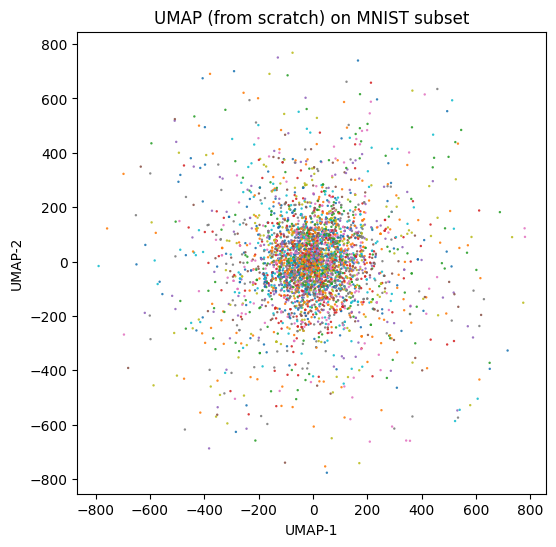

In [2]:
# Load MNIST, subsample, run UMAP-from-scratch, and visualize
rng = np.random.default_rng(123)

mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X = mnist.data.astype(np.float32) / 255.0
y = mnist.target.astype(int)

# Subsample for speed (adjust as needed)
n_samples = 10000
idx = rng.choice(X.shape[0], size=n_samples, replace=False)
X_sub = X[idx]
y_sub = y[idx]

# Run UMAP (from scratch)
Y, P = fit_umap(
    X_sub,
    n_neighbors=15,
    n_components=2,
    n_epochs=200,
    lr=1.0,
    negative_sample_rate=5,
    min_dist=0.1,
    rng=rng,
)

# Plot
plt.figure(figsize=(8, 6))
sc = plt.scatter(Y[:, 0], Y[:, 1], c=y_sub, s=3, cmap='tab10', linewidths=0, alpha=0.9)
plt.gca().set_aspect('equal', 'box')
plt.title('UMAP (from scratch) on MNIST subset')
plt.xlabel('UMAP-1')
plt.ylabel('UMAP-2')
plt.show()